In [1]:
from src.data.column_schema import CANONICAL_TO_LABEL, to_canonical
from src.data.load_data import load_consumption, load_generation
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 8


In [2]:
consumption = load_consumption()
generation = load_generation()

## EDA

### Consumption data 
- `start date` = start of the hour 
- `end date` = end of the hour
- `grid load [MWh] Calculated resolutions` = electricity taken from the grid in that hour
- `Grid load incl. hydro pumped storage [MWh] Calculated resolutions` = electricity taken from the grid + pumped-storage pumping consumption
- `Hydro pumped storage [MWh] Calculated resolutions` = electricity used for pumped-storage pumping
- `Residual load [MWh] Calculated resolutions` = grid load not covered by wind and solar (our target)

In [3]:
consumption.describe()

,Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
count,17544,17544,17544,17544,17544,17544
unique,17542,17540,17281,17297,10977,17361
top,"Oct 27, 2024 2:00 AM","Mar 30, 2024 2:00 AM","60,174.25","62,996.50",1.00,"15,885.75"
freq,2,2,3,3,74,3


In [4]:
consumption.head(5)

,Start date,End date,grid load [MWh] Calculated resolutions,Grid load incl. hydro pumped storage [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Residual load [MWh] Calculated resolutions
0,"Mar 1, 2024 12:00 AM","Mar 1, 2024 1:00 AM","49,611.50","51,275.50","1,664.00","28,610.50"
1,"Mar 1, 2024 1:00 AM","Mar 1, 2024 2:00 AM","48,075.75","50,337.00","2,261.25","27,862.75"
2,"Mar 1, 2024 2:00 AM","Mar 1, 2024 3:00 AM","47,663.00","51,471.00","3,808.00","27,326.25"
3,"Mar 1, 2024 3:00 AM","Mar 1, 2024 4:00 AM","48,234.00","52,043.75","3,809.75","27,592.75"
4,"Mar 1, 2024 4:00 AM","Mar 1, 2024 5:00 AM","49,060.50","51,579.25","2,518.75","28,203.00"


In [5]:
consumption.isna().sum()

Start date                                                           0
End date                                                             0
grid load [MWh] Calculated resolutions                               0
Grid load incl. hydro pumped storage [MWh] Calculated resolutions    0
Hydro pumped storage [MWh] Calculated resolutions                    0
Residual load [MWh] Calculated resolutions                           0
dtype: int64

In [6]:
consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 6 columns):
 #   Column                                                             Non-Null Count  Dtype 
---  ------                                                             --------------  ----- 
 0   Start date                                                         17544 non-null  object
 1   End date                                                           17544 non-null  object
 2   grid load [MWh] Calculated resolutions                             17544 non-null  object
 3   Grid load incl. hydro pumped storage [MWh] Calculated resolutions  17544 non-null  object
 4   Hydro pumped storage [MWh] Calculated resolutions                  17544 non-null  object
 5   Residual load [MWh] Calculated resolutions                         17544 non-null  object
dtypes: object(6)
memory usage: 822.5+ KB


Check if the dataset is structurally clean.
* We want to confirm:

    - Start date can be parsed as datetime
    - End date can be parsed as datetime
    - rows are sorted by time
    - every interval is exactly 1 hour
    - no duplicate timestamps
    - no missing hourly timestamps
    - target column is numeric
    - no nulls / weird text values in target

In [7]:
df_consumption_clean = consumption.copy()

In [8]:
# Parse the datetime columns. 
for col in ["Start date", "End date"]:
    df_consumption_clean[col] = (
        pd.to_datetime(df_consumption_clean[col]))


# Canonical modeling layer
df_consumption_clean = to_canonical(df_consumption_clean)

# Make sure numeric columns are typed consistently
date_cols = ["timestamp", "end_timestamp"]
numeric_cols = [col for col in df_consumption_clean.columns if col not in date_cols]

df_consumption_clean[numeric_cols] = df_consumption_clean[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "", regex=False), errors="coerce")
)

# Convert to UTC to avoid ambihuity during DST transitions.
df_consumption_clean['timestamp'] = df_consumption_clean['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert('UTC')
df_consumption_clean["end_timestamp"] = df_consumption_clean["timestamp"] + pd.Timedelta(hours=1)

/tmp/ipykernel_18778/2751414081.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_consumption_clean[col]))


In [9]:
# Then validate structure
print(df_consumption_clean[["timestamp", "end_timestamp", "residual_load_mwh"]].dtypes)

print("Nulls:")
print(df_consumption_clean[["timestamp", "end_timestamp", "residual_load_mwh"]].isna().sum())

print("Duplicate timestamps:", df_consumption_clean["timestamp"].duplicated().sum())

print("Sorted:", df_consumption_clean["timestamp"].is_monotonic_increasing)

timestamp            datetime64[ns, UTC]
end_timestamp        datetime64[ns, UTC]
residual_load_mwh                float64
dtype: object
Nulls:
timestamp            0
end_timestamp        0
residual_load_mwh    0
dtype: int64
Duplicate timestamps: 0
Sorted: True


In [10]:
df_consumption_clean['timestamp'].min(), df_consumption_clean['timestamp'].max()

(Timestamp('2024-02-29 23:00:00+0000', tz='UTC'),
 Timestamp('2026-03-01 22:00:00+0000', tz='UTC'))

In [11]:
# Check that each row is really one hour
duration = df_consumption_clean["end_timestamp"] - df_consumption_clean["timestamp"]
print("Unique durations:", duration.unique())

# Check for missing hours
df_consumption_clean = df_consumption_clean.sort_values("timestamp").reset_index(drop=True)

expected = pd.date_range(
    start=df_consumption_clean["timestamp"].min(),
    end=df_consumption_clean["timestamp"].max(),
    freq="h"
)

missing_hours = expected.difference(df_consumption_clean["timestamp"])
print("Missing hours:", len(missing_hours))

Unique durations: <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[ns]
Missing hours: 0


The -1 difference and 2 missing hours suggest Day-light saving hours. We will inspect those rows to confirm whether our suspicion is correct

In [12]:
bad_rows = df_consumption_clean[(df_consumption_clean["end_timestamp"] - df_consumption_clean["timestamp"]) != pd.Timedelta(hours=1)]
bad_rows[["timestamp", "end_timestamp", "residual_load_mwh"]]

# df_consumption_clean["timestamp"].duplicated().sum()

,timestamp,end_timestamp,residual_load_mwh


Our suspicion is correct, the problematic rows are due to DST

### Generation data

In [13]:
generation.describe()

,Other renewable [MWh] Calculated resolutions
count,17544.000000
mean,110.271202
std,14.007210
min,56.460000
25%,100.477500
50%,109.600000
75%,119.000000
max,145.750000


In [14]:
generation.head()

,Start date,End date,Biomass [MWh] Calculated resolutions,Hydropower [MWh] Calculated resolutions,Wind offshore [MWh] Calculated resolutions,Wind onshore [MWh] Calculated resolutions,Photovoltaics [MWh] Calculated resolutions,Other renewable [MWh] Calculated resolutions,Nuclear [MWh] Calculated resolutions,Lignite [MWh] Calculated resolutions,Hard coal [MWh] Calculated resolutions,Fossil gas [MWh] Calculated resolutions,Hydro pumped storage [MWh] Calculated resolutions,Other conventional [MWh] Calculated resolutions
0,"Mar 1, 2024 12:00 AM","Mar 1, 2024 1:00 AM","4,235.50","1,821.25","5,285.75","15,712.25",3.00,120.75,-,"8,705.75","2,809.50","6,887.75",21.50,"1,864.00"
1,"Mar 1, 2024 1:00 AM","Mar 1, 2024 2:00 AM","4,201.25","1,844.50","5,180.75","15,029.00",3.25,121.00,-,"8,255.25","2,784.25","6,396.00",50.75,"1,814.50"
2,"Mar 1, 2024 2:00 AM","Mar 1, 2024 3:00 AM","4,167.75","1,792.75","5,542.25","14,791.50",3.00,121.50,-,"8,141.25","2,770.00","6,075.50",11.75,"1,806.25"
3,"Mar 1, 2024 3:00 AM","Mar 1, 2024 4:00 AM","4,163.75","1,812.75","5,914.50","14,723.50",3.25,121.00,-,"8,194.00","2,731.25","6,089.50",2.75,"1,837.00"
4,"Mar 1, 2024 4:00 AM","Mar 1, 2024 5:00 AM","4,213.50","1,854.25","5,981.00","14,873.25",3.25,121.00,-,"8,283.25","2,770.00","6,522.75",39.00,"1,828.75"


In [15]:
generation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 14 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Start date                                         17544 non-null  object 
 1   End date                                           17544 non-null  object 
 2   Biomass [MWh] Calculated resolutions               17544 non-null  object 
 3   Hydropower [MWh] Calculated resolutions            17544 non-null  object 
 4   Wind offshore [MWh] Calculated resolutions         17544 non-null  object 
 5   Wind onshore [MWh] Calculated resolutions          17544 non-null  object 
 6   Photovoltaics [MWh] Calculated resolutions         17544 non-null  object 
 7   Other renewable [MWh] Calculated resolutions       17544 non-null  float64
 8   Nuclear [MWh] Calculated resolutions               17544 non-null  object 
 9   Lignit

In [16]:
generation.isna().sum() 

Start date                                           0
End date                                             0
Biomass [MWh] Calculated resolutions                 0
Hydropower [MWh] Calculated resolutions              0
Wind offshore [MWh] Calculated resolutions           0
Wind onshore [MWh] Calculated resolutions            0
Photovoltaics [MWh] Calculated resolutions           0
Other renewable [MWh] Calculated resolutions         0
Nuclear [MWh] Calculated resolutions                 0
Lignite [MWh] Calculated resolutions                 0
Hard coal [MWh] Calculated resolutions               0
Fossil gas [MWh] Calculated resolutions              0
Hydro pumped storage [MWh] Calculated resolutions    0
Other conventional [MWh] Calculated resolutions      0
dtype: int64

In [17]:
df_generation_clean = generation.copy()

In [18]:
# Parse the datetime columns and convert to UTC to avoid ambihuity during DST transitions. We assume that the timestamps are in local time (Europe/Berlin). 
for col in ["Start date", "End date"]:
    df_generation_clean[col] = (
        pd.to_datetime(df_generation_clean[col]))

# Canonical modeling layer
df_generation_clean = to_canonical(df_generation_clean)

# Make sure input features are numeric
date_cols = ["timestamp", "end_timestamp"]

numeric_cols = [col for col in df_generation_clean.columns if col not in date_cols]

df_generation_clean[numeric_cols] = df_generation_clean[numeric_cols].apply(
    lambda col: pd.to_numeric(col.astype(str).str.replace(",", "", regex=False), errors="coerce")
)

# Convert to UTC to avoid ambihuity during DST transitions.
df_generation_clean['timestamp'] = df_generation_clean['timestamp'].dt.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="shift_forward").dt.tz_convert('UTC')
df_generation_clean["end_timestamp"] = df_generation_clean["timestamp"] + pd.Timedelta(hours=1)


/tmp/ipykernel_18778/1433854016.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_generation_clean[col]))


In [19]:
df_generation_clean.dtypes

timestamp                   datetime64[ns, UTC]
end_timestamp               datetime64[ns, UTC]
biomass_mwh                             float64
hydropower_mwh                          float64
wind_offshore_mwh                       float64
wind_onshore_mwh                        float64
photovoltaics_mwh                       float64
other_renewable_mwh                     float64
nuclear_mwh                             float64
lignite_mwh                             float64
hard_coal_mwh                           float64
fossil_gas_mwh                          float64
hydro_pumped_storage_mwh                float64
other_conventional_mwh                  float64
dtype: object

In [20]:
# Then validate structure
print(df_generation_clean[["timestamp", "end_timestamp"]].dtypes)

print("Nulls:")
print(df_generation_clean[["timestamp", "end_timestamp"]].isna().sum())

print("Duplicate timestamps:", df_generation_clean["timestamp"].duplicated().sum())

print("Sorted:", df_generation_clean["timestamp"].is_monotonic_increasing)

timestamp        datetime64[ns, UTC]
end_timestamp    datetime64[ns, UTC]
dtype: object
Nulls:
timestamp        0
end_timestamp    0
dtype: int64
Duplicate timestamps: 0
Sorted: True


In [21]:
df_generation_clean['timestamp'].min(), df_generation_clean['timestamp'].max()

(Timestamp('2024-02-29 23:00:00+0000', tz='UTC'),
 Timestamp('2026-03-01 22:00:00+0000', tz='UTC'))

In [22]:
## Check if both datasets have the same timestamps (i.e. same rows, just different columns)
df_generation_clean["timestamp"].equals(df_consumption_clean["timestamp"])


True

## Merge Dfs

In [23]:
df_merged = df_consumption_clean.merge(
    df_generation_clean,
    on=["timestamp","end_timestamp"],
    how="inner"
)
df_merged.shape


(17544, 18)

In [24]:
df_merged = df_merged.sort_values("timestamp").reset_index(drop=True)

expected = pd.date_range(df_merged["timestamp"].min(), df_merged["timestamp"].max(), freq="h")
missing = expected.difference(df_merged["timestamp"])

print("missing hours:", len(missing))


missing hours: 0


In [25]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype              
---  ------                             --------------  -----              
 0   timestamp                          17544 non-null  datetime64[ns, UTC]
 1   end_timestamp                      17544 non-null  datetime64[ns, UTC]
 2   grid_load_mwh                      17544 non-null  float64            
 3   grid_load_incl_pumped_storage_mwh  17544 non-null  float64            
 4   hydro_pumped_storage_mwh_x         17544 non-null  float64            
 5   residual_load_mwh                  17544 non-null  float64            
 6   biomass_mwh                        17544 non-null  float64            
 7   hydropower_mwh                     17544 non-null  float64            
 8   wind_offshore_mwh                  17544 non-null  float64            
 9   wind_onshore_mwh                   17544 non-null 

In [26]:
## Validating the residual load by comparing it to the calculated residual load from the generation data
renewable_cols = [
    # "Biomass [MWh] Calculated resolutions",
    # "Hydropower [MWh] Calculated resolutions",
    "wind_offshore_mwh",
    "wind_onshore_mwh",
    "photovoltaics_mwh",
    # "Other renewable [MWh] Calculated resolutions",
]

df_merged["calculated_renewable_generation_mwh"] = df_merged[renewable_cols].sum(axis=1)

df_merged["calculated_residual_load_mwh"] = (
    df_merged["grid_load_mwh"] - df_merged["calculated_renewable_generation_mwh"]
)

comparison_cols = [
    "timestamp",
    "residual_load_mwh",
    "calculated_residual_load_mwh",
]

df_merged[comparison_cols].head()


,timestamp,residual_load_mwh,calculated_residual_load_mwh
0,2024-02-29 23:00:00+00:00,28610.50,28610.50
1,2024-03-01 00:00:00+00:00,27862.75,27862.75
2,2024-03-01 01:00:00+00:00,27326.25,27326.25
3,2024-03-01 02:00:00+00:00,27592.75,27592.75
4,2024-03-01 03:00:00+00:00,28203.00,28203.00


In [27]:
df_merged[df_merged["residual_load_mwh"]<0]

,timestamp,end_timestamp,grid_load_mwh,grid_load_incl_pumped_storage_mwh,hydro_pumped_storage_mwh_x,residual_load_mwh,biomass_mwh,hydropower_mwh,wind_offshore_mwh,wind_onshore_mwh,photovoltaics_mwh,other_renewable_mwh,nuclear_mwh,lignite_mwh,hard_coal_mwh,fossil_gas_mwh,hydro_pumped_storage_mwh_y,other_conventional_mwh,calculated_renewable_generation_mwh,calculated_residual_load_mwh
204,2024-03-09 11:00:00+00:00,2024-03-09 12:00:00+00:00,54543.75,60266.75,5723.00,-806.50,4155.00,1822.75,5806.25,14472.50,35071.50,112.75,NaN,3386.00,2427.75,3818.25,72.00,1931.50,55350.25,-806.50
205,2024-03-09 12:00:00+00:00,2024-03-09 13:00:00+00:00,52573.00,58089.75,5516.75,-550.25,4142.25,1796.25,5885.50,14939.00,32298.75,110.00,NaN,3385.50,2370.00,3829.50,126.00,1937.25,53123.25,-550.25
781,2024-04-02 12:00:00+00:00,2024-04-02 13:00:00+00:00,61327.00,66847.25,5520.25,-701.50,4020.50,1852.00,4007.50,34782.50,23238.50,106.00,NaN,2746.25,2059.50,3432.00,32.50,1988.25,62028.50,-701.50
1066,2024-04-14 09:00:00+00:00,2024-04-14 10:00:00+00:00,48688.50,54400.50,5712.00,-1768.50,3746.50,1654.50,2146.75,16203.50,32106.75,101.00,NaN,2519.50,1072.00,2570.00,91.25,1753.50,50457.00,-1768.50
1067,2024-04-14 10:00:00+00:00,2024-04-14 11:00:00+00:00,47411.00,53252.50,5841.50,-2115.25,3687.00,1674.75,1963.25,13226.75,34336.25,100.00,NaN,2509.25,1078.50,2532.75,100.25,1700.50,49526.25,-2115.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16118,2026-01-01 13:00:00+00:00,2026-01-01 14:00:00+00:00,52128.46,55248.32,3119.85,-2673.23,4268.33,922.19,5143.22,44728.86,4929.62,98.25,NaN,2590.52,4000.45,4270.65,145.01,1795.30,54801.70,-2673.24
16128,2026-01-01 23:00:00+00:00,2026-01-02 00:00:00+00:00,45217.37,47146.23,1928.86,-107.72,4102.67,801.75,3504.67,41820.43,0.00,97.45,NaN,2671.21,4459.40,4639.43,165.73,1838.35,45325.10,-107.73
16129,2026-01-02 00:00:00+00:00,2026-01-02 01:00:00+00:00,44267.52,48379.95,4112.43,-1325.51,4080.99,816.32,3612.16,41980.86,0.00,97.45,NaN,2673.71,4616.82,4520.59,2.96,1794.44,45593.02,-1325.50
16130,2026-01-02 01:00:00+00:00,2026-01-02 02:00:00+00:00,43562.70,48070.86,4508.16,-2497.23,4066.67,822.53,4078.82,41981.11,0.00,97.45,NaN,2686.08,4744.01,4446.90,0.40,1755.32,46059.93,-2497.23


## Exploring the final df

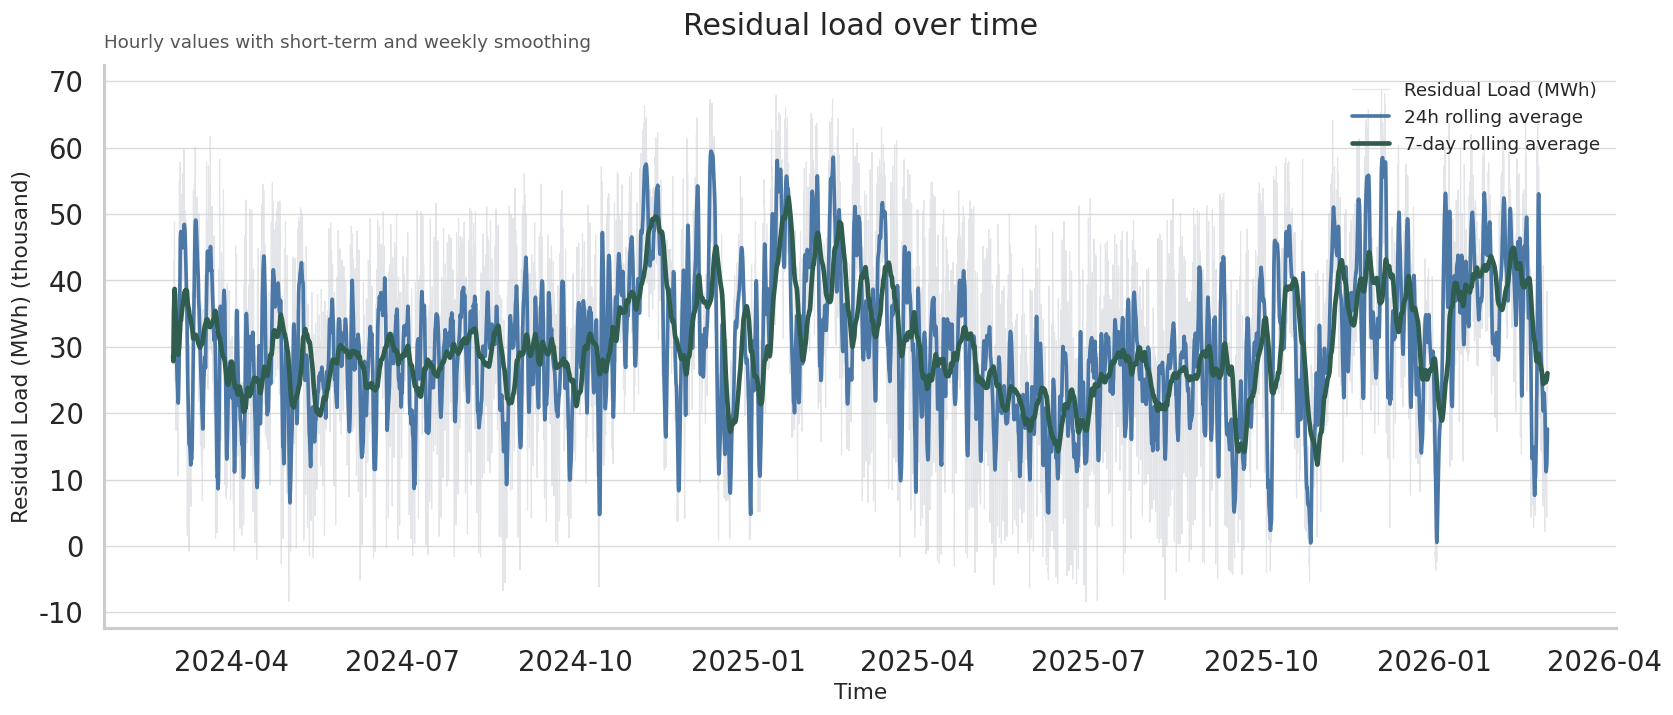

In [28]:
df_plot = df_merged.copy()

# Ensure clean, sorted time series
df_plot["timestamp"] = pd.to_datetime(df_plot["timestamp"], errors="coerce")
df_plot = (
    df_plot
    .dropna(subset=["timestamp", "residual_load_mwh"])
    .sort_values("timestamp")
)

# Rolling averages
df_plot["residual_load_ma_24h"] = (
    df_plot["residual_load_mwh"].rolling(window=24, min_periods=1).mean()
)
df_plot["residual_load_ma_168h"] = (
    df_plot["residual_load_mwh"].rolling(window=168, min_periods=1).mean()
)

fig, ax = plt.subplots(figsize=(14, 6))

# Raw hourly series
sns.lineplot(
    data=df_plot,
    x="timestamp",
    y="residual_load_mwh",
    ax=ax,
    label=CANONICAL_TO_LABEL["residual_load_mwh"],
    color="#C9CDD3",
    alpha=0.5,
    linewidth=0.7,
)

# Smoothed trends
sns.lineplot(
    data=df_plot,
    x="timestamp",
    y="residual_load_ma_24h",
    ax=ax,
    label="24h rolling average",
    color="#4C78A8",
    linewidth=2.2,
)

sns.lineplot(
    data=df_plot,
    x="timestamp",
    y="residual_load_ma_168h",
    ax=ax,
    label="7-day rolling average",
    color="#2F5D50",
    linewidth=2.8,
)

# Titles
ax.set_title("Residual load over time", fontsize=18, pad=18)
ax.text(
    0, 1.03,
    "Hourly values with short-term and weekly smoothing",
    transform=ax.transAxes,
    fontsize=11,
    color="#555555"
)

# Labels
ax.set_xlabel("Time", fontsize=13)
ax.set_ylabel(f"{CANONICAL_TO_LABEL['residual_load_mwh']} (thousand)", fontsize=13)

# Format y-axis to thousands
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f"{x/1000:.0f}"))

# Styling
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(frameon=False, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

### Time-Series Insights: Residual Load

From the residual load time-series (hourly) and rolling averages (24h, 168h), we observe:

1. **Pronounced seasonality**
   Residual load is generally **higher in winter months** (around Nov-Feb) and **lower in late spring/summer** (around May-Aug), indicating strong seasonal demand effects.

2. **Medium-term trend changes**
   The **168h rolling average** declines into mid-2025 (lower baseline), then rises again in late-2025 to early-2026, suggesting a regime shift rather than a purely flat long-run trend.

3. **Strong short-term variability**
   The hourly series shows substantial fluctuation around the smoothed trend, consistent with **intra-day and intra-week demand dynamics**.

4. **Winter peak concentration**
   High-load spikes (frequently above 50,000 MWh) are concentrated in colder periods, reinforcing the role of weather-driven demand pressure.

5. **Low/near-zero (and occasional negative) residual-load hours**
   These occur mostly around lower-demand/high-renewable periods and can reflect **renewable surplus conditions**. They should also be checked for data-quality consistency.

6. **Time-varying volatility**
   Variability is not constant across the sample; some periods show wider spread and more abrupt swings, which suggests potential benefit from models that can handle heteroskedastic behavior.


In [ ]:
df_subset = df_plot[["timestamp", "residual_load_mwh", "grid_load_mwh"]].copy()

df_subset_monthly = (
    df_subset
    .set_index("timestamp")
    .resample("ME")
    .agg(
        monthly_grid_load=("grid_load_mwh", "sum"),
        monthly_residual_load=("residual_load_mwh", "sum"),
    )
    .reset_index()
)

df_subset_monthly = df_subset_monthly.iloc[1:-1].copy() ## dropping first and last month as they are incomplete

df_subset_monthly["residual_share_pct"] = (
    df_subset_monthly["monthly_residual_load"] / df_subset_monthly["monthly_grid_load"] * 100
)
df_subset_monthly["month_year"] = df_subset_monthly["timestamp"].dt.strftime("%Y-%m")
df_subset_monthly["monthly_grid_load_twh"] = df_subset_monthly["monthly_grid_load"] / 1_000_000
df_subset_monthly["monthly_residual_load_twh"] = df_subset_monthly["monthly_residual_load"] / 1_000_000

SEASON_MAP = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn",
}
df_subset_monthly["season"] = df_subset_monthly["timestamp"].dt.month.map(SEASON_MAP)
df_subset_monthly["below_50"] = df_subset_monthly["residual_share_pct"] < 50


def annotate_seasons(ax, df, y_position=None, y_mult=1.01):
    season_change_idx = [
        i for i in range(1, len(df))
        if df["season"].iloc[i] != df["season"].iloc[i - 1]
    ]
    for i in season_change_idx:
        ax.axvline(i - 0.5, color="#BDBDBD", linestyle=":", linewidth=1.2)

    if y_position is None:
        y_position = ax.get_ylim()[1] * y_mult

    start = 0
    for i in range(1, len(df) + 1):
        if i == len(df) or df["season"].iloc[i] != df["season"].iloc[i - 1]:
            end = i - 1
            center = (start + end) / 2
            ax.text(
                center,
                y_position,
                df["season"].iloc[start],
                ha="center",
                va="bottom",
                fontsize=10,
                color="#666666",
            )
            start = i


df_subset_monthly.head()


,timestamp,monthly_grid_load,monthly_residual_load,residual_share_pct,month_year,monthly_grid_load_twh,monthly_residual_load_twh,season,below_50
1,2024-03-31 00:00:00+00:00,40215235.75,23254594.50,57.825334,2024-03,40.215236,23.254594,Spring,False
2,2024-04-30 00:00:00+00:00,37735926.75,19238340.75,50.981498,2024-04,37.735927,19.238341,Spring,False
3,2024-05-31 00:00:00+00:00,35985886.00,19617547.00,54.514559,2024-05,35.985886,19.617547,Spring,False
4,2024-06-30 00:00:00+00:00,35704925.50,19654136.00,55.046008,2024-06,35.704926,19.654136,Summer,False
5,2024-07-31 00:00:00+00:00,36980536.00,20510794.75,55.463757,2024-07,36.980536,20.510795,Summer,False


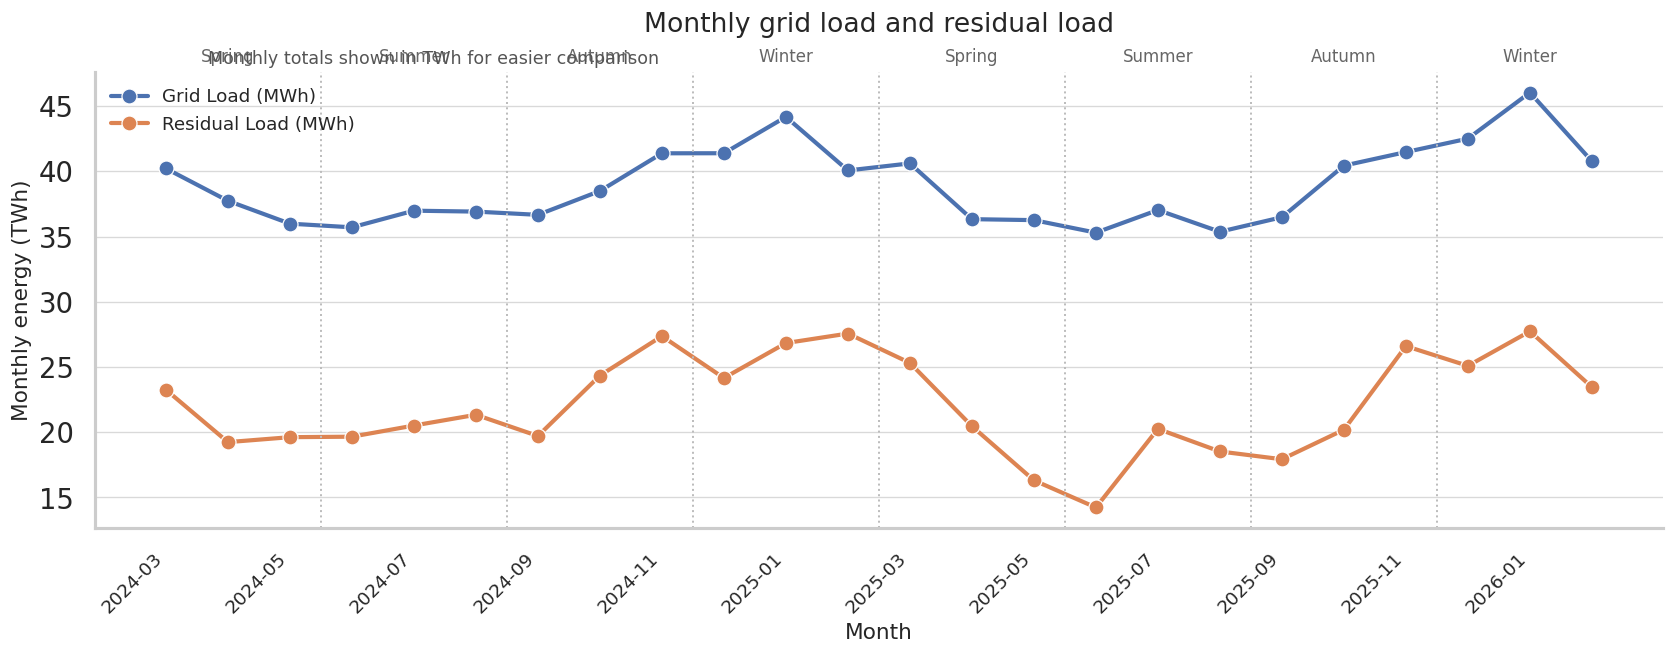

In [30]:
fig, ax = plt.subplots(figsize=(14, 5.5))

sns.lineplot(
    data=df_subset_monthly,
    x="month_year",
    y="monthly_grid_load_twh",
    marker="o",
    linewidth=2.5,
    label=CANONICAL_TO_LABEL["grid_load_mwh"],
    ax=ax,
)
sns.lineplot(
    data=df_subset_monthly,
    x="month_year",
    y="monthly_residual_load_twh",
    marker="o",
    linewidth=2.5,
    label=CANONICAL_TO_LABEL["residual_load_mwh"],
    ax=ax,
)

# show every 2nd month label
xticks = ax.get_xticks()
xlabels = [lab.get_text() for lab in ax.get_xticklabels()]
ax.set_xticks(xticks[::2])
ax.set_xticklabels(xlabels[::2], rotation=45, ha="right", fontsize=11)

# soft styling
ax.set_ylabel("Monthly energy (TWh)", fontsize=13)
ax.set_xlabel("Month", fontsize=13)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="x", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

annotate_seasons(ax, df_subset_monthly, y_mult=1.01)

ax.set_title("Monthly grid load and residual load", fontsize=16, pad=24)
fig.text(
    0.125,
    0.90,
    "Monthly totals shown in TWh for easier comparison",
    fontsize=10.5,
    color="#555555",
)

ax.legend(frameon=False, fontsize=11, loc="upper left")
plt.tight_layout()
plt.show()


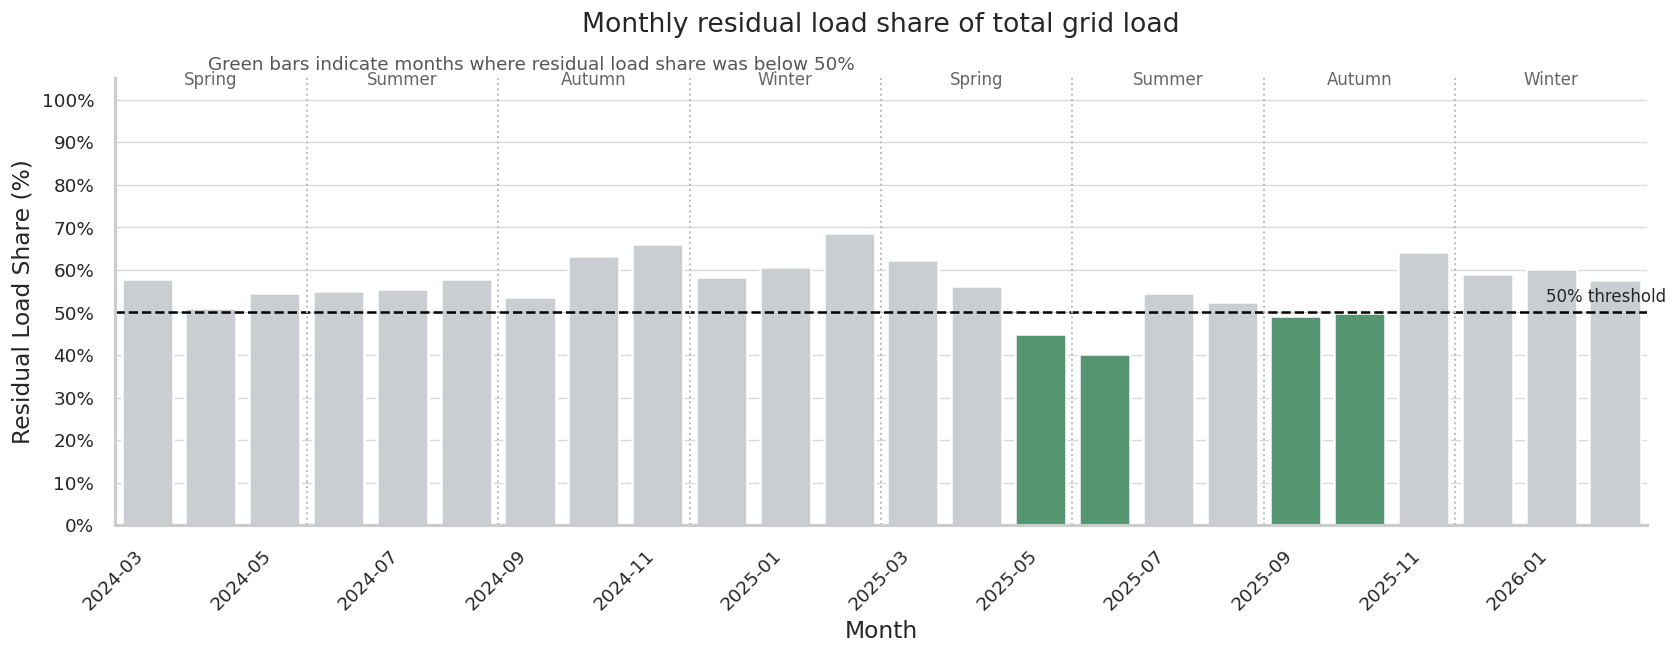

In [31]:
fig, ax = plt.subplots(figsize=(14, 5.5))

sns.barplot(
    data=df_subset_monthly,
    x="month_year",
    y="residual_share_pct",
    hue="below_50",
    palette={True: "#4C9F70", False: "#C9CDD3"},
    dodge=False,
    legend=False,
    ax=ax,
)

# threshold line
ax.axhline(50, color="black", linestyle="--", linewidth=1.5)
ax.text(len(df_subset_monthly) - 0.2, 51.5, "50% threshold", ha="right", va="bottom", fontsize=10)

# axes
ax.set_ylim(0, 105)
ax.set_ylabel(CANONICAL_TO_LABEL["residual_share_pct"], fontsize=14)
ax.set_xlabel("Month", fontsize=14)
ax.set_yticks(range(0, 101, 10))
ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)], fontsize=11)

# show every 2nd month only
xticks = ax.get_xticks()
xlabels = [lab.get_text() for lab in ax.get_xticklabels()]
ax.set_xticks(xticks[::2])
ax.set_xticklabels(xlabels[::2], rotation=45, ha="right", fontsize=11)

# lighter grid
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="x", visible=False)

# remove extra spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

annotate_seasons(ax, df_subset_monthly, y_position=102.5)

# title + subtitle
ax.set_title(
    "Monthly residual load share of total grid load",
    fontsize=16,
    pad=28,
)
fig.text(
    0.125,
    0.89,
    "Green bars indicate months where residual load share was below 50%",
    fontsize=11,
    color="#555555",
)

plt.tight_layout()
plt.show()


### Correlation plot
For ML feature selection, we want to learn about correlation of target (residual load) with other features
1. plot correlation of each feature with the target `residual_load_mwh`
2. Make a small heatmap of only the most relevant numeric features

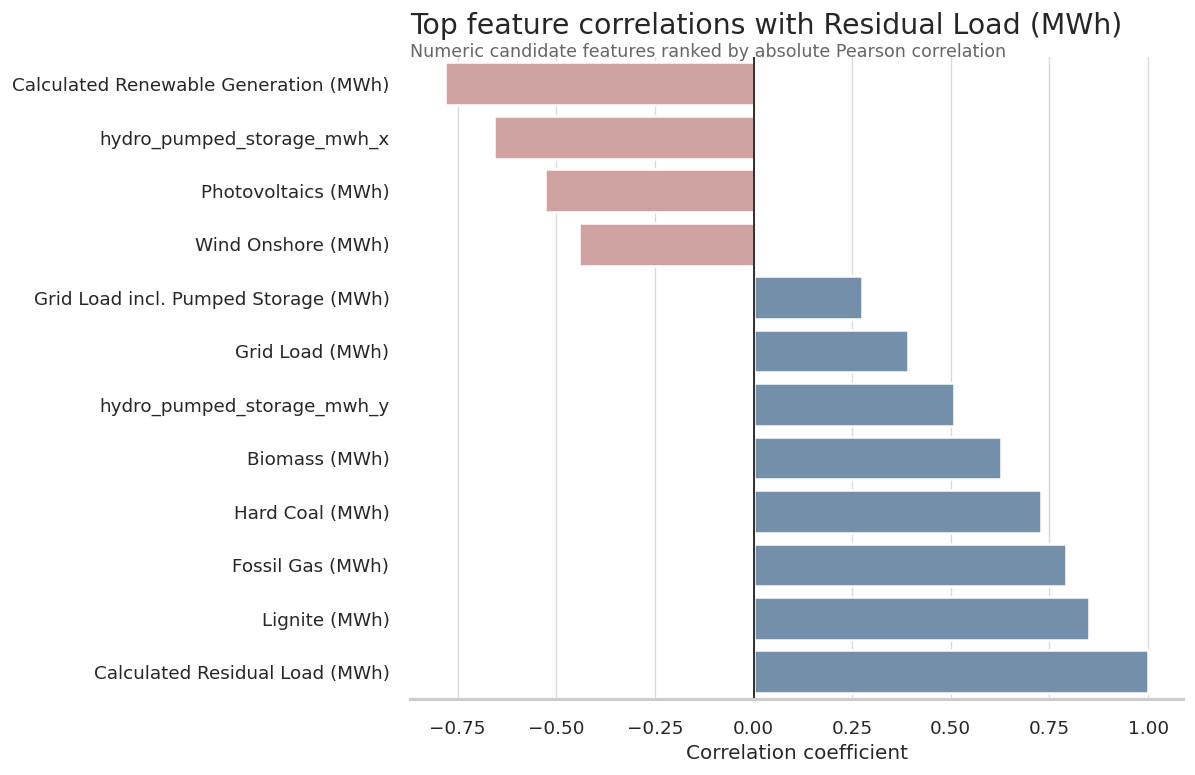

In [32]:
target = "residual_load_mwh"

# keep only numeric columns
corr_df = df_merged.select_dtypes(include="number").copy()

# correlation of all numeric features with target
target_corr = (
    corr_df.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

plot_df = target_corr.reset_index()
plot_df.columns = ["feature", "correlation"]
plot_df["feature_label"] = plot_df["feature"].map(CANONICAL_TO_LABEL).fillna(plot_df["feature"])


# keep top 12 by absolute correlation, then sort for plotting
plot_df["abs_corr"] = plot_df["correlation"].abs()
plot_df = (
    plot_df
    .sort_values("abs_corr", ascending=False)
    .head(12)
    .sort_values("correlation")
)

plot_df["direction"] = plot_df["correlation"].ge(0).map({True: "Positive", False: "Negative"})

fig, ax = plt.subplots(figsize=(10, 6.5))

sns.barplot(
    data=plot_df,
    x="correlation",
    y="feature_label",
    hue="direction",
    dodge=False,
    palette={"Positive": "#6B8FB3", "Negative": "#D79A9A"},
    ax=ax,
)

# remove legend
if ax.legend_:
    ax.legend_.remove()

# zero reference line
ax.axvline(0, color="#333333", linewidth=1.2)

# titles
target_label = CANONICAL_TO_LABEL.get(target, target)
ax.set_title(f"Top feature correlations with {target_label}", fontsize=17, pad=14, loc="left")
ax.text(
    0, 1.00,
    "Numeric candidate features ranked by absolute Pearson correlation",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

# labels
ax.set_xlabel("Correlation coefficient", fontsize=12)
ax.set_ylabel("")

# styling
ax.grid(axis="x", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="y", visible=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=11)

plt.tight_layout()
plt.show()

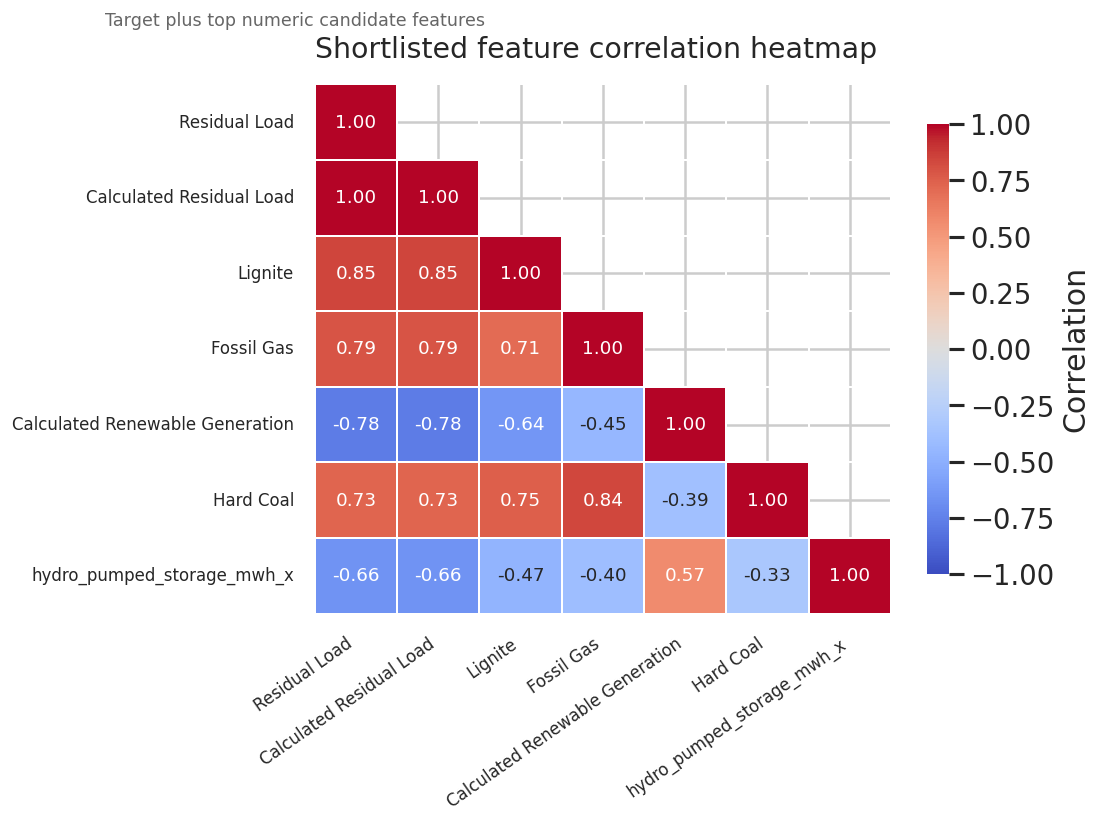

In [33]:
selected_features = target_corr.head(6).index.tolist()
heatmap_cols = [target] + selected_features

corr_small = corr_df[heatmap_cols].corr()

# use schema labels
corr_small = corr_small.rename(index=CANONICAL_TO_LABEL, columns=CANONICAL_TO_LABEL)

# optional: shorten labels a bit for plotting
corr_small = corr_small.rename(
    index=lambda s: s.replace(" (MWh)", ""),
    columns=lambda s: s.replace(" (MWh)", ""),
)

# show only lower triangle
mask = np.triu(np.ones_like(corr_small, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr_small,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor="white",
    square=False,
    cbar_kws={"shrink": 0.85, "label": "Correlation"},
    annot_kws={"size": 11},
    ax=ax,
)

ax.set_title("Shortlisted feature correlation heatmap", fontsize=17, pad=16, loc="left")
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

fig.text(
    0.125,
    0.92,
    "Target plus top numeric candidate features",
    fontsize=10.5,
    color="#666666",
)

plt.subplots_adjust(left=0.30, bottom=0.22, top=0.85)
plt.show()
